In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset


  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached aiohttp-3.14.3-cp313-cp313-win_amd64.whl.metadata (8.5 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.me


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
dataset = load_dataset("dair-ai/emotion")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

c:\Users\karth\OneDrive\Desktop\DL_NLP_PROJECT\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\karth\.cache\huggingface\hub\datasets--dair-ai--emotion. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

...

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [6]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [7]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

In [8]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (16000, 2)
Test shape: (2000, 2)


In [9]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    16000 non-null  str  
 1   label   16000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.7 MB


In [11]:
train_df["label"].value_counts().sort_index()

label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64

In [12]:
label_names = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}

In [13]:
train_df["emotion"] = train_df["label"].map(label_names)
test_df["emotion"] = test_df["label"].map(label_names)

In [14]:
train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [15]:
train_df.isnull().sum()

text       0
label      0
emotion    0
dtype: int64

In [16]:
test_df.isnull().sum()

text       0
label      0
emotion    0
dtype: int64

In [17]:
print("Train duplicates:", train_df["text"].duplicated().sum())
print("Test duplicates:", test_df["text"].duplicated().sum())

Train duplicates: 31
Test duplicates: 0


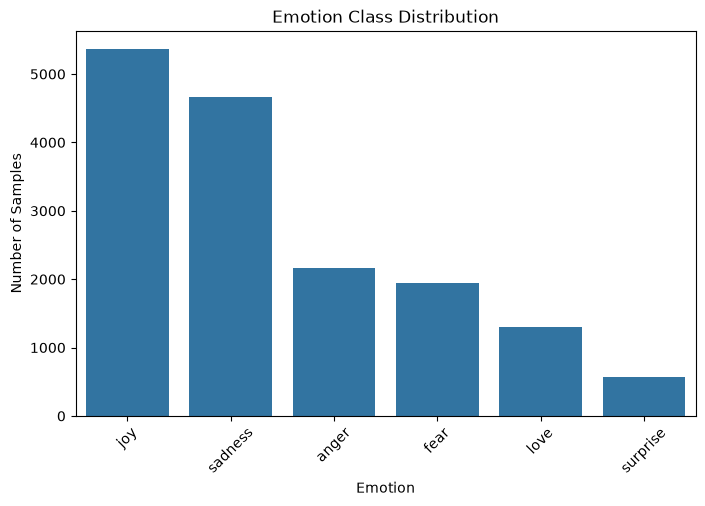

In [18]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="emotion",
    order=train_df["emotion"].value_counts().index
)

plt.title("Emotion Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

In [19]:
train_df["word_count"] = train_df["text"].str.split().str.len()

In [20]:
train_df["word_count"].describe()

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: word_count, dtype: float64

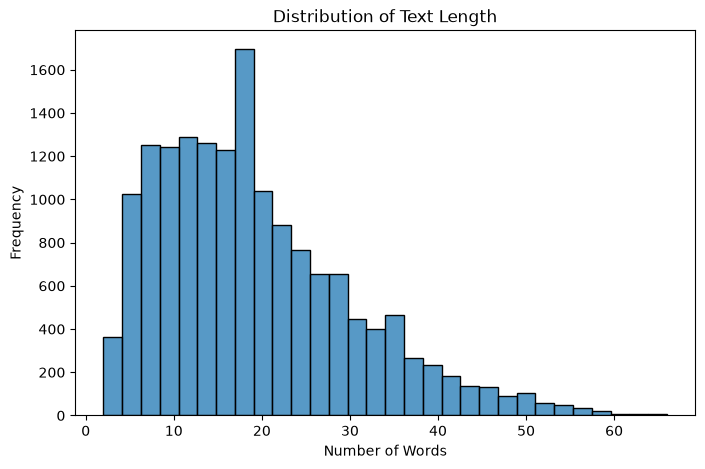

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    train_df["word_count"],
    bins=30
)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [22]:
for emotion in label_names.values():
    print(f"\n===== {emotion.upper()} =====")
    
    samples = train_df[
        train_df["emotion"] == emotion
    ]["text"].sample(3, random_state=42)
    
    for text in samples:
        print("-", text)


===== SADNESS =====
- im feeling so lousy they tried to cheer me up during school time and during choir practice
- i feel highly disadvantaged
- i feel humiliated to introduce you to my colleagues as my wife

===== JOY =====
- i feel im rather innocent in that respect
- im feeling quite adventurous and tried out those drinks that i just normally read through the pages of pocketbooks
- im feeling much more positive about the impending move

===== LOVE =====
- i mean fuck i feel like i was way more considerate with customers and concerned about appearance and sanitiation snoozel pm but fine
- i remember a couple of years ago i was feeling romantic and dreamy and asked him wonder if we ll celebrate our th anniversary
- im so going to end up feeling slutty and be like ah

===== ANGER =====
- i ve been feeling a bit cranky with the kids this week cranky baby whiny year old demanding preschooler so i wanted to stop and remember how blessed i really am
- i feel frustrated sometimes with my m

In [23]:
train_df[["text", "label"]].to_csv(
    "../data/raw/train.csv",
    index=False
)

test_df[["text", "label"]].to_csv(
    "../data/raw/test.csv",
    index=False
)